##**Task 4: 20240802159**

## 1) Fetch a random image (2159)

Button(description='Generate New Image', style=ButtonStyle())

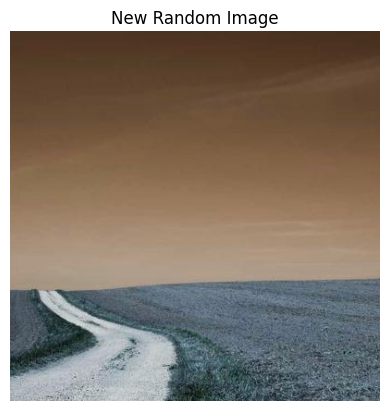

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from ipywidgets import interact, IntSlider, Dropdown, Button

def get_random_image():
    url = "https://picsum.photos/400/400"
    response = requests.get(url)
    image_data = BytesIO(response.content)
    pil_image = Image.open(image_data)
    return cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

def new_image():
    global image, gray, binary
    image = get_random_image()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

    plt.imshow(image)
    plt.title("New Random Image")
    plt.axis("off")

button = Button(description="Generate New Image")
button.on_click(lambda x: new_image())
button

## 2) Convert to binary (2159)

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

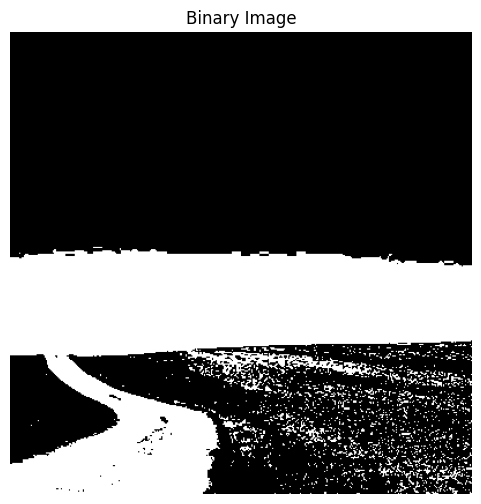

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(6,6))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

## 3) Apply Morphological Operations (2159)

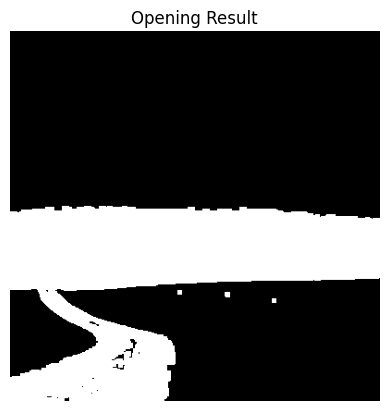

In [ ]:
# (A) Opening
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

plt.imshow(opening, cmap='gray')
plt.title("Opening Result")
plt.axis('off')
plt.show()

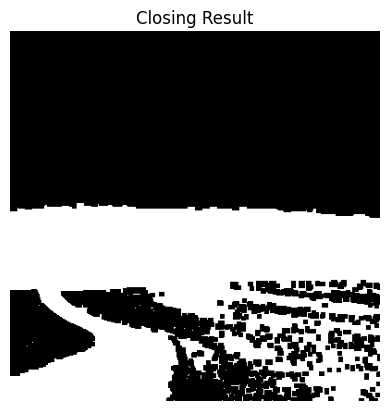

In [ ]:
# (B) Closing
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.imshow(closing, cmap='gray')
plt.title("Closing Result")
plt.axis('off')
plt.show()

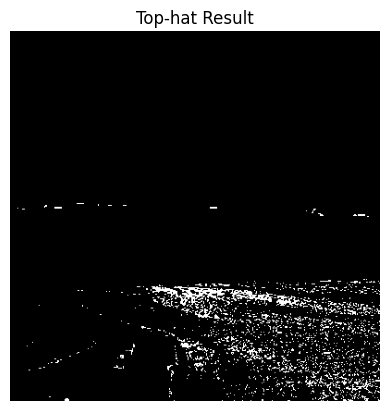

In [ ]:
# (C) Top Hat
tophat = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)

plt.imshow(tophat, cmap='gray')
plt.title("Top-hat Result")
plt.axis('off')
plt.show()

## 4) Different Kernel Sizes (2159)

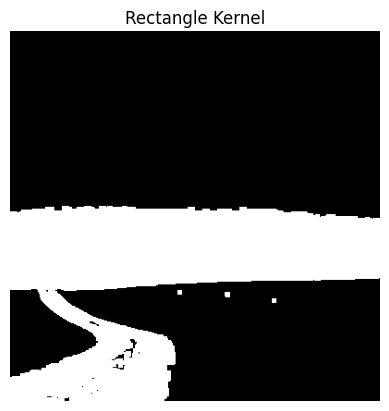

In [ ]:
# Rectangle
rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
rect_result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, rect)

plt.imshow(rect_result, cmap='gray')
plt.title("Rectangle Kernel")
plt.axis('off')
plt.show()

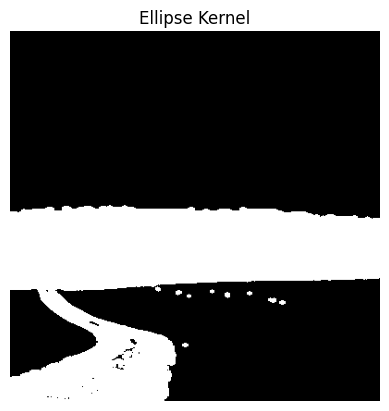

In [ ]:
# Ellipse
ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
ellipse_result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, ellipse)

plt.imshow(ellipse_result, cmap='gray')
plt.title("Ellipse Kernel")
plt.axis('off')
plt.show()

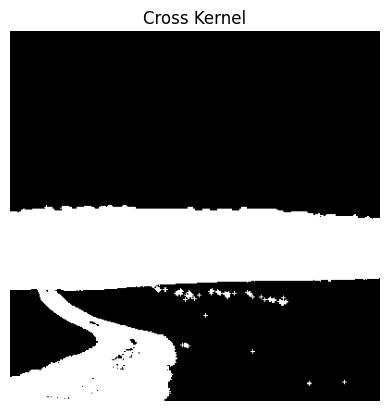

In [ ]:
# Cross
cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))
cross_result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, cross)

plt.imshow(cross_result, cmap='gray')
plt.title("Cross Kernel")
plt.axis('off')
plt.show()

## Final Comparision (2159)

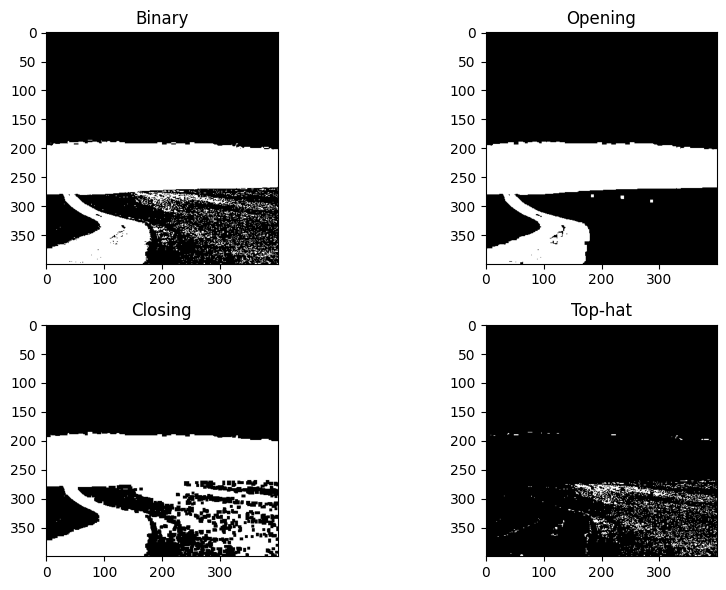

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(binary, cmap='gray')
plt.title("Binary")

plt.subplot(2,2,2)
plt.imshow(opening, cmap='gray')
plt.title("Opening")

plt.subplot(2,2,3)
plt.imshow(closing, cmap='gray')
plt.title("Closing")

plt.subplot(2,2,4)
plt.imshow(tophat, cmap='gray')
plt.title("Top-hat")

plt.tight_layout()
plt.show()

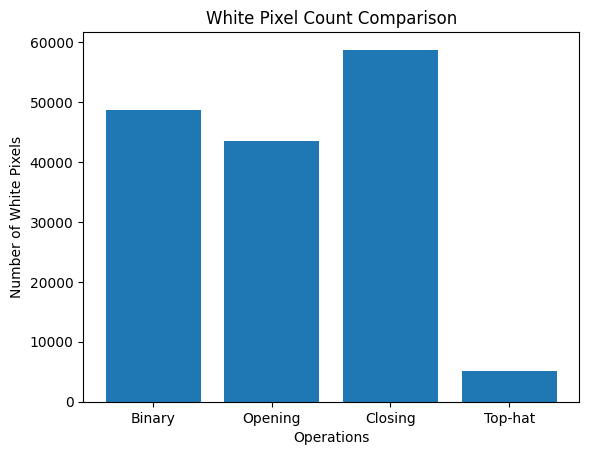

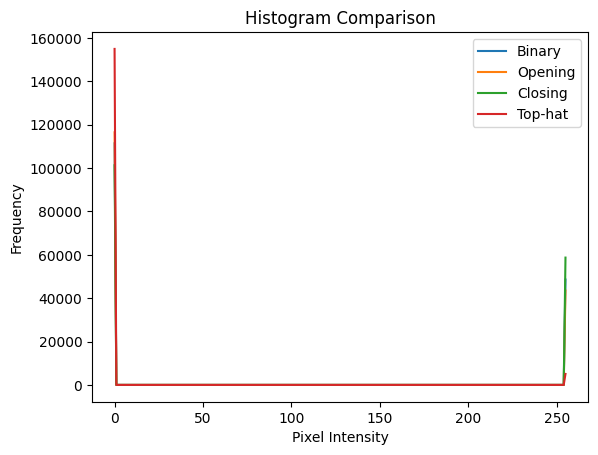

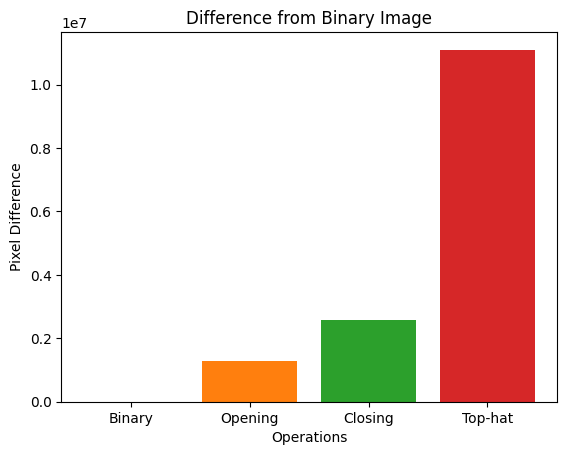

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Count white pixels (useful metric for morphology comparison)
def count_white_pixels(img):
    return np.sum(img == 255)

# Store results
images = {
    "Binary": binary,
    "Opening": opening,
    "Closing": closing,
    "Top-hat": tophat
}

#Bar Graph
labels = list(images.keys())
white_counts = [count_white_pixels(img) for img in images.values()]

plt.figure()
plt.bar(labels, white_counts)
plt.title("White Pixel Count Comparison")
plt.xlabel("Operations")
plt.ylabel("Number of White Pixels")
plt.show()

#Histogram
plt.figure()

for name, img in images.items():
    hist = cv2.calcHist([img], [0], None, [256], [0,256])
    plt.plot(hist, label=name)

plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Diff Graph
plt.figure()

for name, img in images.items():
    diff = cv2.absdiff(binary, img)
    diff_count = np.sum(diff)
    plt.bar(name, diff_count)

plt.title("Difference from Binary Image")
plt.xlabel("Operations")
plt.ylabel("Pixel Difference")
plt.show()